In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import shap

In [ ]:
import sys
print(sys.executable)

In [2]:
import sys
!{sys.executable} -m pip install shap

  Using cached shap-0.52.0-cp312-abi3-win_amd64.whl.metadata (26 kB)
  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
Using cached shap-0.52.0-cp312-abi3-win_amd64.whl (499 kB)
Using cached slicer-0.0.8-py3-none-any.whl (15 kB)

   ---------------------------------------- 0/2 [slicer]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   ---------------------------------------- 2/2 [shap]



In [3]:
import shap
print(shap.__version__)

0.52.0


In [5]:
df=pd.read_csv(r"C:\Users\selva\OneDrive\Desktop\credit_risk_dataset.csv")

In [6]:
df

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
...,...,...,...,...,...,...,...,...,...,...,...,...
32576,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,0.11,N,30
32577,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,0.15,N,19
32578,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,N,28
32579,56,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0,0.10,N,26


In [7]:
print(df.shape)
print(df.info())
print(df.isnull().sum())


(32581, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB
None
person_age    

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")


In [9]:
print("Shape:", df.shape)
print("\nColumns:\n", df.columns)


Shape: (32581, 12)

Columns:
 Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length'],
      dtype='object')


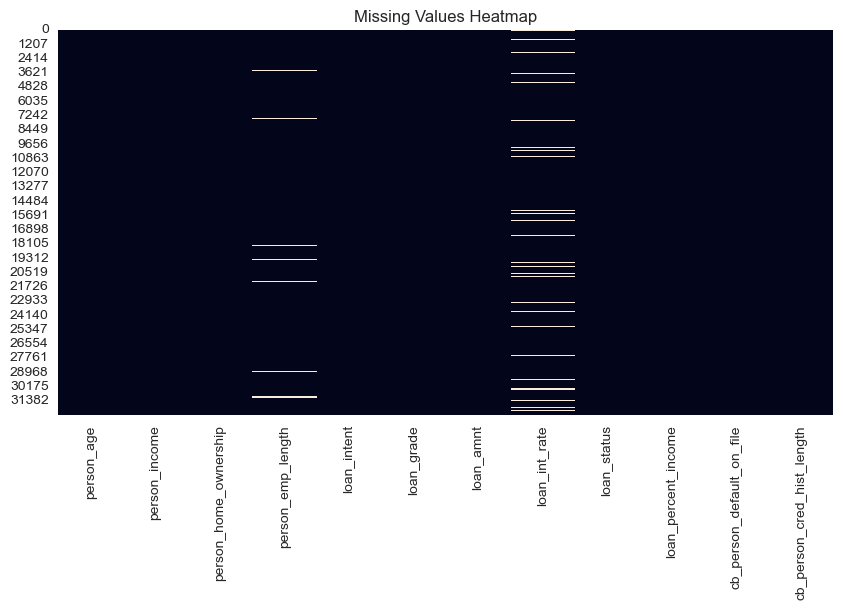

In [10]:
plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

In [11]:

df['person_emp_length'].fillna(df['person_emp_length'].median(), inplace=True)
df['loan_int_rate'].fillna(df['loan_int_rate'].median(), inplace=True)


C:\Users\selva\AppData\Local\Temp\ipykernel_4648\466771703.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['person_emp_length'].fillna(df['person_emp_length'].median(), inplace=True)
C:\Users\selva\AppData\Local\Temp\ipykernel_4648\466771703.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always b

In [12]:
df.isnull().sum()

person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64

In [13]:
df.isnull().sum()

person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64

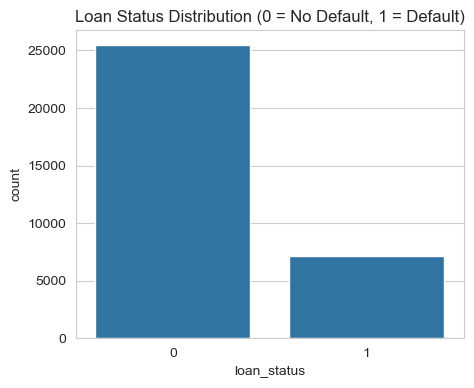

loan_status
0    25473
1     7108
Name: count, dtype: int64


In [14]:
plt.figure(figsize=(5,4))
sns.countplot(x="loan_status", data=df)
plt.title("Loan Status Distribution (0 = No Default, 1 = Default)")
plt.show()

print(df["loan_status"].value_counts())


In [15]:
class_0 = df[df.loan_status == 0]
class_1 = df[df.loan_status == 1]

print(class_0.shape, class_1.shape)

(25473, 12) (7108, 12)


In [16]:
class_0_under = class_0.sample(len(class_1), random_state=42)

In [17]:
df_balanced = pd.concat([class_0_under, class_1])


In [18]:
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)


In [19]:

print(df_balanced.loan_status.value_counts())


loan_status
0    7108
1    7108
Name: count, dtype: int64


In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_style("whitegrid")


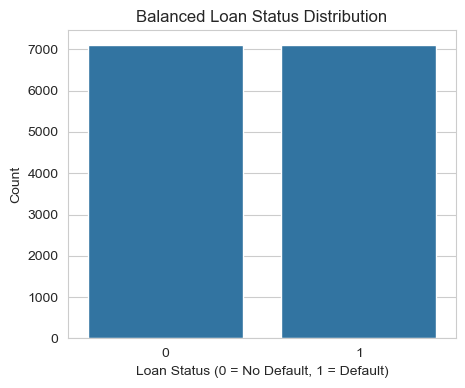

In [21]:
plt.figure(figsize=(5,4))

sns.countplot(x="loan_status", data=df_balanced)

plt.title("Balanced Loan Status Distribution")
plt.xlabel("Loan Status (0 = No Default, 1 = Default)")
plt.ylabel("Count")

plt.show()


In [22]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import seaborn as sns
import matplotlib.pyplot as plt

In [23]:
le = LabelEncoder()

for col in df_balanced.select_dtypes(include='object'):
    df_balanced[col] = le.fit_transform(df_balanced[col])


In [24]:
X = df_balanced.drop("loan_status", axis=1)
y = df_balanced["loan_status"]


In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [26]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [27]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [28]:
y_pred = lr.predict(X_test)

In [29]:
print("Logistic Regression Accuracy:",
      accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Logistic Regression Accuracy: 0.7827004219409283

Classification Report:

              precision    recall  f1-score   support

           0       0.78      0.79      0.78      1422
           1       0.78      0.78      0.78      1422

    accuracy                           0.78      2844
   macro avg       0.78      0.78      0.78      2844
weighted avg       0.78      0.78      0.78      2844



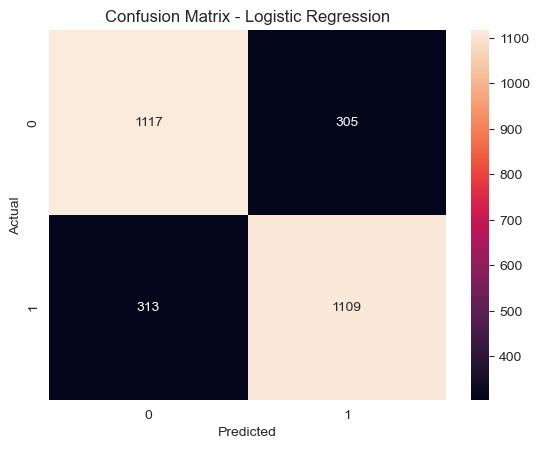

In [30]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [31]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr.coef_[0]
})

importance = importance.sort_values(by="Coefficient", ascending=False)

print(importance)

                       Feature  Coefficient
8          loan_percent_income     1.410761
5                   loan_grade     1.182250
2        person_home_ownership     0.275851
0                   person_age     0.032187
1                person_income     0.003912
3            person_emp_length    -0.000119
9    cb_person_default_on_file    -0.015407
7                loan_int_rate    -0.020549
10  cb_person_cred_hist_length    -0.025262
4                  loan_intent    -0.207635
6                    loan_amnt    -0.577070


In [32]:
df['person_emp_length'] = df['person_emp_length'].fillna(df['person_emp_length'].median())

df['loan_int_rate'] = df['loan_int_rate'].fillna(df['loan_int_rate'].median())



In [33]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

cols = ['person_home_ownership','loan_intent','loan_grade','cb_person_default_on_file']

for c in cols:
    df[c] = le.fit_transform(df[c])


In [34]:
X = df.drop('loan_status', axis=1)
y = df['loan_status']


In [35]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

model = RandomForestClassifier()
model.fit(X_train,y_train)

pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test,pred))


Accuracy: 0.9300291545189504


In [36]:
import joblib
joblib.dump(model, "loan_model.pkl")


['loan_model.pkl']